# Tas vs Tas

Historical

Figure saved as 'Global_vs_Regional_Temp_0.png'


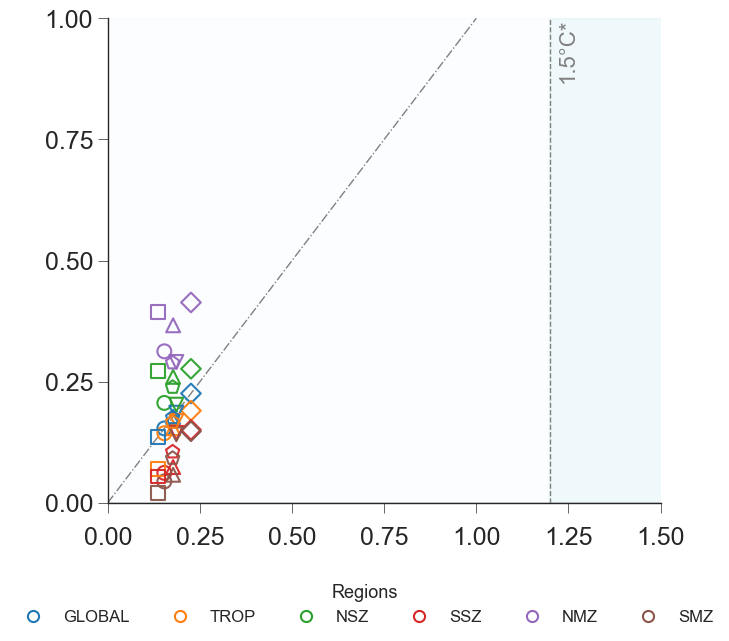

In [26]:
# With Legend
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Enable interactive plotting for VS Code
plt.ion()  # Turn on interactive mode

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_GlobalVSEverything.xlsx"

# === LOAD DATA ===
df = pd.read_excel(file_path, sheet_name="Sheet1")

# === FILTER FOR HISTORICAL PERIOD ONLY ===
df = df[df["Period"] == "Historical"]

# === MODEL MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === REGION COLORS ===
region_colors = {
    'Global': '#1f77b4',
    'Tropics': '#ff7f0e',
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}
regions_order = list(region_colors.keys())

# === FILTER DATA ===
df = df[df["Region"].isin(regions_order)].copy()
df["Region"] = pd.Categorical(df["Region"], categories=regions_order, ordered=True)

# === PLOTTING ===
sns.set(style="ticks", context="talk")
fig, ax = plt.subplots(figsize=(7, 6))

# === Define axis limits first ===
x_vals = df["Global_Temp_change_°C"]
y_vals = df["Regional_change_°C"]

# Compute overall max needed (including IPCC lines)
data_max = max(x_vals.max(), y_vals.max(), 2.0)
lims_max = 1.5

# === ADD BACKGROUND COLOR REGIONS ===
# Light red background for 0 < X < 1.2
ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)

# Darker red background for 1.2 < X < 1.5
ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)

# === Scatter plotting: manually draw per model for marker shape control
for model, marker in model_markers.items():
    sub = df[df["Model"] == model]
    for _, row in sub.iterrows():
        color = region_colors.get(row["Region"], "gray")
        
        # All markers are unfilled (outline only)
        ax.scatter(
            row["Global_Temp_change_°C"],
            row["Regional_change_°C"],
            marker=marker,
            s=100,
            edgecolor=color,
            facecolor='none',  # No fill for all markers
            linewidth=1.5,     # Slightly thicker edge for better visibility
            alpha=0.95,
            zorder=3          # Make sure markers are on top
        )

# Set axis limits
ax.set_xlim(0, lims_max)
ax.set_ylim(0, 1.0)

# Set ticks every 0.25°C
ax.set_xticks(np.arange(0, lims_max + 0.001, 0.25))
ax.set_yticks(np.arange(0, 1 + 0.001, 0.25))

# === Reference lines
ax.plot([0, 1.0], [0, 1.0], '-.', color='gray', linewidth=1, label="1:1 Reference")
ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1, zorder=2)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=1, zorder=2)  # solid y=0 line

# Inline labels at end of lines
ax.text(1.2 + 0.02, 1.0, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')

# Customize tick appearance to make them visible and sharp
ax.tick_params(
    axis='both',
    which='major',
    length=7,        # Tick length (in points)
    width=0.5,       # Tick line width
    direction='out', # 'in', 'out', or 'inout'
    labelsize=18     # Font size of tick labels
)

# === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.0)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_linewidth(1.0)

# Move X-axis to Y=0
ax.spines['bottom'].set_position(('data', 0))

# Move X-axis tick labels to Y=0
ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0

# === Custom Legend for Regions + Reference
legend_elements = (
    [Line2D([0], [0], marker='o', color='w', label=region,
            markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
     for region, color in region_colors.items()] +
    [
        Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limits (1.5°C, 2.0°C)")
    ]
)

# === Create Legend Elements ===
# Region colors legend
region_legend = [
    Line2D([0], [0], marker='o', color='w', label='GLOBAL',
           markerfacecolor='none', markeredgecolor=region_colors['Global'], 
           markersize=8, markeredgewidth=1.5, linestyle='None'),
    Line2D([0], [0], marker='o', color='w', label='TROP',
           markerfacecolor='none', markeredgecolor=region_colors['Tropics'], 
           markersize=8, markeredgewidth=1.5, linestyle='None'),
    Line2D([0], [0], marker='o', color='w', label='NSZ',
           markerfacecolor='none', markeredgecolor=region_colors['Subtropics_N'], 
           markersize=8, markeredgewidth=1.5, linestyle='None'),
    Line2D([0], [0], marker='o', color='w', label='SSZ',
           markerfacecolor='none', markeredgecolor=region_colors['Subtropics_S'], 
           markersize=8, markeredgewidth=1.5, linestyle='None'),
    Line2D([0], [0], marker='o', color='w', label='NMZ',
           markerfacecolor='none', markeredgecolor=region_colors['Mid_Latitudes_N'], 
           markersize=8, markeredgewidth=1.5, linestyle='None'),
    Line2D([0], [0], marker='o', color='w', label='SMZ',
           markerfacecolor='none', markeredgecolor=region_colors['Mid_Latitudes_S'], 
           markersize=8, markeredgewidth=1.5, linestyle='None'),

]

# Add legends below the subplots
legend1 = fig.legend(handles=region_legend, loc='lower center', 
                     bbox_to_anchor=(0.5, -0.1), ncol=6, frameon=False, 
                     fontsize=12, title='Regions', title_fontsize=13)

# === REMOVE GRID ===
ax.grid(False)

# === DISPLAY AND SAVE ===
plt.tight_layout(pad=1.2)

# Save the figure BEFORE showing it
plt.savefig("Global_vs_Regional_Temp_0.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_vs_Regional_Temp_0.png'")

# Display in VS Code (interactive)
plt.show()

Figure saved as 'Global_vs_Regional_Temp_0.png'


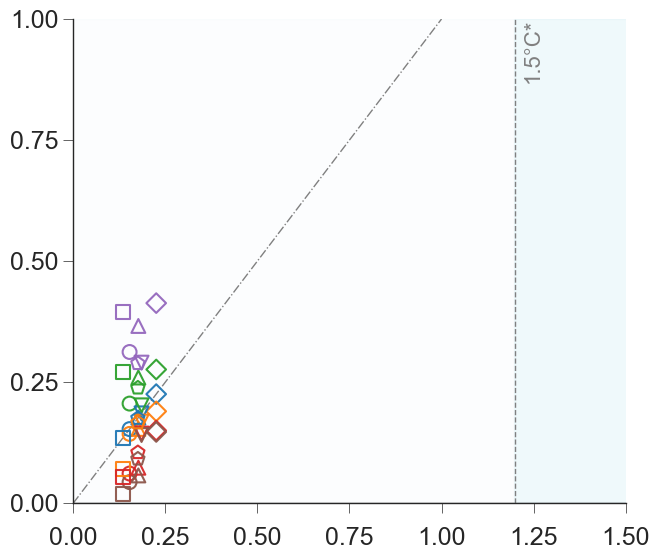

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Enable interactive plotting for VS Code
plt.ion()  # Turn on interactive mode

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_GlobalVSEverything.xlsx"

# === LOAD DATA ===
df = pd.read_excel(file_path, sheet_name="Sheet1")

# === FILTER FOR HISTORICAL PERIOD ONLY ===
df = df[df["Period"] == "Historical"]

# === MODEL MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === REGION COLORS ===
region_colors = {
    'Global': '#1f77b4',
    'Tropics': '#ff7f0e',
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}
regions_order = list(region_colors.keys())

# === FILTER DATA ===
df = df[df["Region"].isin(regions_order)].copy()
df["Region"] = pd.Categorical(df["Region"], categories=regions_order, ordered=True)

# === PLOTTING ===
sns.set(style="ticks", context="talk")
fig, ax = plt.subplots(figsize=(7, 6))

# === Define axis limits first ===
x_vals = df["Global_Temp_change_°C"]
y_vals = df["Regional_change_°C"]

# Compute overall max needed (including IPCC lines)
data_max = max(x_vals.max(), y_vals.max(), 2.0)
lims_max = 1.5

# === ADD BACKGROUND COLOR REGIONS ===
# Light red background for 0 < X < 1.2
ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)

# Darker red background for 1.2 < X < 1.5
ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)

# === Scatter plotting: manually draw per model for marker shape control
for model, marker in model_markers.items():
    sub = df[df["Model"] == model]
    for _, row in sub.iterrows():
        color = region_colors.get(row["Region"], "gray")
        
        # All markers are unfilled (outline only)
        ax.scatter(
            row["Global_Temp_change_°C"],
            row["Regional_change_°C"],
            marker=marker,
            s=100,
            edgecolor=color,
            facecolor='none',  # No fill for all markers
            linewidth=1.5,     # Slightly thicker edge for better visibility
            alpha=0.95,
            zorder=3          # Make sure markers are on top
        )

# Set axis limits
ax.set_xlim(0, lims_max)
ax.set_ylim(0, 1.0)

# Set ticks every 0.25°C
ax.set_xticks(np.arange(0, lims_max + 0.001, 0.25))
ax.set_yticks(np.arange(0, 1 + 0.001, 0.25))

# === Reference lines
ax.plot([0, 1.0], [0, 1.0], '-.', color='gray', linewidth=1, label="1:1 Reference")
ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1, zorder=2)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=1, zorder=2)  # solid y=0 line

# Inline labels at end of lines
ax.text(1.2 + 0.02, 1.0, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')

# Customize tick appearance to make them visible and sharp
ax.tick_params(
    axis='both',
    which='major',
    length=7,        # Tick length (in points)
    width=0.5,       # Tick line width
    direction='out', # 'in', 'out', or 'inout'
    labelsize=18     # Font size of tick labels
)

# === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.0)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_linewidth(1.0)

# Move X-axis to Y=0
ax.spines['bottom'].set_position(('data', 0))

# Move X-axis tick labels to Y=0
ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0

# === Custom Legend for Regions + Reference
legend_elements = (
    [Line2D([0], [0], marker='o', color='w', label=region,
            markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
     for region, color in region_colors.items()] +
    [
        Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limits (1.5°C, 2.0°C)")
    ]
)

# === REMOVE GRID ===
ax.grid(False)

# === DISPLAY AND SAVE ===
plt.tight_layout(pad=1.2)

# Save the figure BEFORE showing it
plt.savefig("Global_vs_Regional_Temp_0.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_vs_Regional_Temp_0.png'")

# Display in VS Code (interactive)
plt.show()

Midterm

Figure saved as 'Global_vs_Regional_Temp_1.png'


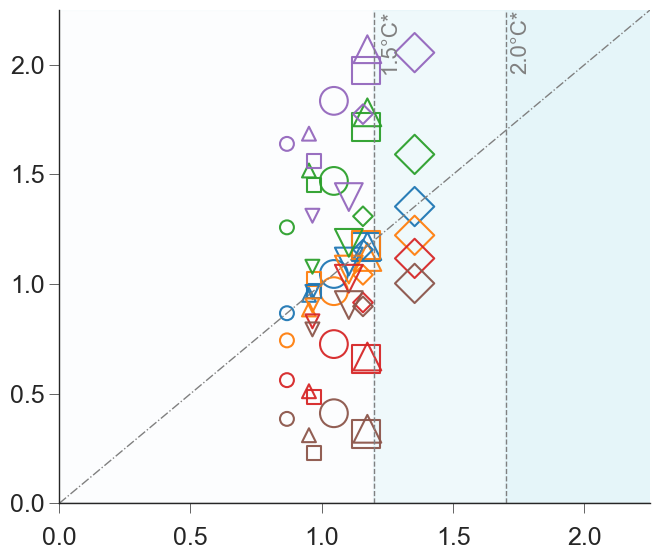

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Enable interactive plotting for VS Code
plt.ion()  # Turn on interactive mode

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_GlobalVSEverything.xlsx"

# === LOAD DATA ===
df = pd.read_excel(file_path, sheet_name="Sheet1")

# === FILTER FOR HISTORICAL PERIOD ONLY ===
df = df[df["Period"].isin(["126_Midterm", "585_Midterm"])]

# === MODEL MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Midterm': 100,   # Smaller size for 126_Midterm
    '585_Midterm': 400    # Larger size for 585_Midterm
}

# === REGION COLORS ===
region_colors = {
    'Global': '#1f77b4',
    'Tropics': '#ff7f0e',
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}
regions_order = list(region_colors.keys())

# === FILTER DATA ===
df = df[df["Region"].isin(regions_order)].copy()
df["Region"] = pd.Categorical(df["Region"], categories=regions_order, ordered=True)

# === PLOTTING ===
sns.set(style="ticks", context="talk")
fig, ax = plt.subplots(figsize=(7, 6))

# === Define axis limits first ===
x_vals = df["Global_Temp_change_°C"]
y_vals = df["Regional_change_°C"]

# Compute overall max needed (including IPCC lines)
data_max = max(x_vals.max(), y_vals.max(), 2.0)
lims_max = 2.25

# === ADD BACKGROUND COLOR REGIONS ===
# Light red background for 0 < X < 1.2
ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)

# Darker red background for 1.2 < X < 1.5
ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
ax.axvspan(1.7, 2.25, alpha=1, color='#e5f5f9', zorder=0)

# === Scatter plotting: manually draw per model for marker shape control
for model, marker in model_markers.items():
    sub = df[df["Model"] == model]
    for _, row in sub.iterrows():
        color = region_colors.get(row["Region"], "gray")
        
        # Get size based on period
        size = period_sizes.get(row["Period"], 40)

        # All markers are unfilled (outline only)
        ax.scatter(
            row["Global_Temp_change_°C"],
            row["Regional_change_°C"],
            marker=marker,
            s=size,
            edgecolor=color,
            facecolor='none',  # No fill for all markers
            linewidth=1.5,     # Slightly thicker edge for better visibility
            alpha=0.95
        )

# Set axis limits
ax.set_xlim(0, lims_max)
ax.set_ylim(0, 2.25)

# Set ticks every 0.25°C
ax.set_xticks(np.arange(0, lims_max + 0.001, 0.5))
ax.set_yticks(np.arange(0, 2.25 + 0.001, 0.5))

# === Reference lines
ax.plot([0, 2.25], [0, 2.25], '-.', color='gray', linewidth=1, label="1:1 Reference")
ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1, zorder=2)
ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1, zorder=2)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=1, zorder=2)  # solid y=0 line

# Inline labels at end of lines
ax.text(1.2 + 0.02, 2.25, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
ax.text(1.7 + 0.02, 2.25, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')

# Customize tick appearance to make them visible and sharp
ax.tick_params(
    axis='both',
    which='major',
    length=7,        # Tick length (in points)
    width=0.5,       # Tick line width
    direction='out', # 'in', 'out', or 'inout'
    labelsize=18     # Font size of tick labels
)

# === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.0)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_linewidth(1.0)

# Move X-axis to Y=0
ax.spines['bottom'].set_position(('data', 0))

# Move X-axis tick labels to Y=0
ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0

# === Custom Legend for Regions + Reference
legend_elements = (
    [Line2D([0], [0], marker='o', color='w', label=region,
            markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
     for region, color in region_colors.items()] +
    [
        Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limits (1.5°C, 2.0°C)")
    ]
)

# === REMOVE GRID ===
ax.grid(False)

# === DISPLAY AND SAVE ===
plt.tight_layout(pad=1.2)

# Save the figure BEFORE showing it
plt.savefig("Global_vs_Regional_Temp_1.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_vs_Regional_Temp_1.png'")

# Display in VS Code (interactive)
plt.show()

Longterm

Figure saved as 'Global_vs_Regional_Temp.png'


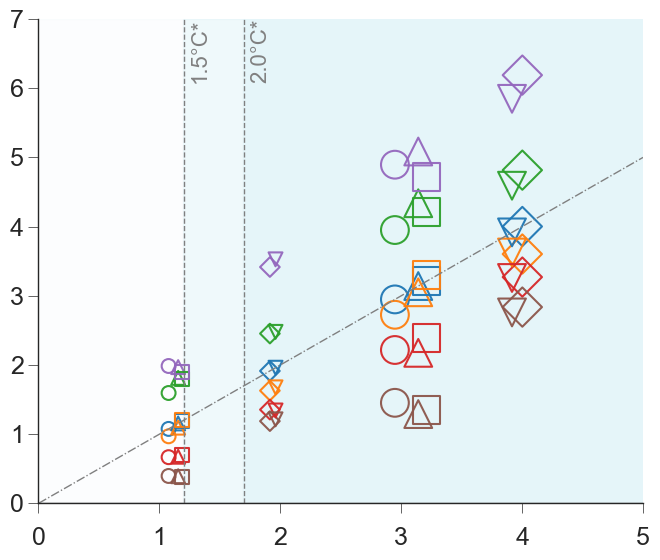

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Enable interactive plotting for VS Code
plt.ion()  # Turn on interactive mode

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_GlobalVSEverything.xlsx"

# === LOAD DATA ===
df = pd.read_excel(file_path, sheet_name="Sheet1")

# === FILTER FOR HISTORICAL PERIOD ONLY ===
df = df[df["Period"].isin(["126_Longterm", "585_Longterm"])]

# === MODEL MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Longterm': 100,   # Smaller size for 126_Midterm
    '585_Longterm': 400    # Larger size for 585_Midterm
}

# === REGION COLORS ===
region_colors = {
    'Global': '#1f77b4',
    'Tropics': '#ff7f0e',
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}
regions_order = list(region_colors.keys())

# === FILTER DATA ===
df = df[df["Region"].isin(regions_order)].copy()
df["Region"] = pd.Categorical(df["Region"], categories=regions_order, ordered=True)

# === PLOTTING ===
sns.set(style="ticks", context="talk")
fig, ax = plt.subplots(figsize=(7, 6))

# === Define axis limits first ===
x_vals = df["Global_Temp_change_°C"]
y_vals = df["Regional_change_°C"]

# Compute overall max needed (including IPCC lines)
data_max = max(x_vals.max(), y_vals.max(), 2.0)
lims_max = 5.0

# === ADD BACKGROUND COLOR REGIONS ===
# Light red background for 0 < X < 1.2
ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)

# Darker red background for 1.2 < X < 1.5
ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
ax.axvspan(1.7, 5.0, alpha=1, color='#e5f5f9', zorder=0)

# === Scatter plotting: manually draw per model for marker shape control
for model, marker in model_markers.items():
    sub = df[df["Model"] == model]
    for _, row in sub.iterrows():
        color = region_colors.get(row["Region"], "gray")
        
        # Get size based on period
        size = period_sizes.get(row["Period"], 40)

        # All markers are unfilled (outline only)
        ax.scatter(
            row["Global_Temp_change_°C"],
            row["Regional_change_°C"],
            marker=marker,
            s=size,
            edgecolor=color,
            facecolor='none',  # No fill for all markers
            linewidth=1.5,     # Slightly thicker edge for better visibility
            alpha=0.95
        )

# Set axis limits
ax.set_xlim(0, lims_max)
ax.set_ylim(0, 7.0)

# Set ticks every 0.25°C
ax.set_xticks(np.arange(0, lims_max + 0.001, 1))
ax.set_yticks(np.arange(0, 7.0 + 0.001, 1))

# === Reference lines
ax.plot([0, 5], [0, 5], '-.', color='gray', linewidth=1, label="1:1 Reference")
ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1, zorder=2)
ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1, zorder=2)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=1, zorder=2)  # solid y=0 line

# Inline labels at end of lines
ax.text(1.2 + 0.05, 7.0, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
ax.text(1.7 + 0.05, 7.0, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')

# Customize tick appearance to make them visible and sharp
ax.tick_params(
    axis='both',
    which='major',
    length=7,        # Tick length (in points)
    width=0.5,       # Tick line width
    direction='out', # 'in', 'out', or 'inout'
    labelsize=18     # Font size of tick labels
)

# === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.0)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_linewidth(1.0)

# Move X-axis to Y=0
ax.spines['bottom'].set_position(('data', 0))

# Move X-axis tick labels to Y=0
ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0

# === Custom Legend for Regions + Reference
legend_elements = (
    [Line2D([0], [0], marker='o', color='w', label=region,
            markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
     for region, color in region_colors.items()] +
    [
        Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limits (1.5°C, 2.0°C)")
    ]
)

# === REMOVE GRID ===
ax.grid(False)

# === DISPLAY AND SAVE ===
plt.tight_layout(pad=1.2)

# Save the figure BEFORE showing it
plt.savefig("Global_vs_Regional_Temp_2.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_vs_Regional_Temp.png'")

# Display in VS Code (interactive)
plt.show()

# Tas vs Prw

Historical

Figure saved as 'Global_vs_Prw0.png'


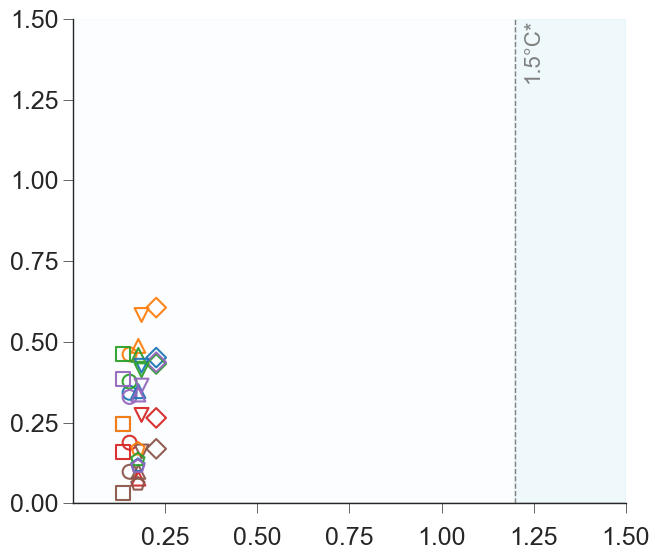

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Enable interactive plotting for VS Code
plt.ion()  # Turn on interactive mode

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_GlobalVSPrw.xlsx"

# === LOAD DATA ===
df = pd.read_excel(file_path, sheet_name="Sheet1")

# === FILTER FOR HISTORICAL PERIOD ONLY ===
df = df[df["Period"] == "Historical"]

# === MODEL MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === REGION COLORS ===
region_colors = {
    'Global': '#1f77b4',
    'Tropics': '#ff7f0e',
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}
regions_order = list(region_colors.keys())

# === FILTER DATA ===
df = df[df["Region"].isin(regions_order)].copy()
df["Region"] = pd.Categorical(df["Region"], categories=regions_order, ordered=True)

# === PLOTTING ===
sns.set(style="ticks", context="talk")
fig, ax = plt.subplots(figsize=(7, 6))

# === Define axis limits first ===
x_vals = df["Global_Temp_change_°C"]
y_vals = df["Regional_change_mm"]

# Compute overall max needed (including IPCC lines)
data_max = max(x_vals.max(), y_vals.max(), 2.0)
lims_max = 1.5

# === ADD BACKGROUND COLOR REGIONS ===
# Light red background for 0 < X < 1.2
ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)

# Darker red background for 1.2 < X < 1.5
ax.axvspan(1.2, 1.5, alpha=0.6, color='#e5f5f9', zorder=0)

# === Scatter plotting: manually draw per model for marker shape control
for model, marker in model_markers.items():
    sub = df[df["Model"] == model]
    for _, row in sub.iterrows():
        color = region_colors.get(row["Region"], "gray")
        
        # All markers are unfilled (outline only)
        ax.scatter(
            row["Global_Temp_change_°C"],
            row["Regional_change_mm"],
            marker=marker,
            s=100,
            edgecolor=color,
            facecolor='none',  # No fill for all markers
            linewidth=1.5,     # Slightly thicker edge for better visibility
            alpha=0.95,
            zorder=3          # Make sure markers are on top
        )

# Set axis limits
ax.set_xlim(0, lims_max)
ax.set_ylim(0, 1.5)

# Set ticks every 0.25°C
ax.set_xticks(np.arange(0.25, lims_max + 0.01, 0.25))
ax.set_yticks(np.arange(0, 1.5 + 0.01, 0.25))

# === Reference lines
ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1, zorder=2)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=1, zorder=2)  # solid y=0 line

# Inline labels at end of lines
ax.text(1.2 + 0.02, 1.5, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')

# Customize tick appearance to make them visible and sharp
ax.tick_params(
    axis='both',
    which='major',
    length=7,        # Tick length (in points)
    width=0.5,       # Tick line width
    direction='out', # 'in', 'out', or 'inout'
    labelsize=18     # Font size of tick labels
)

# === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.0)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_linewidth(1.0)

# Move X-axis to Y=0
ax.spines['bottom'].set_position(('data', 0))

# Move X-axis tick labels to Y=0
ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0

# === Custom Legend for Regions + Reference
legend_elements = (
    [Line2D([0], [0], marker='o', color='w', label=region,
            markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
     for region, color in region_colors.items()] +
    [
        Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limits (1.5°C, 2.0°C)")
    ]
)

# === REMOVE GRID ===
ax.grid(False)

# === DISPLAY AND SAVE ===
plt.tight_layout(pad=1.2)

# Save the figure BEFORE showing it
plt.savefig("Global_vs_Prw0.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_vs_Prw0.png'")

# Display in VS Code (interactive)
plt.show()

Midterm

Figure saved as 'Global_vs_Prw1.png'


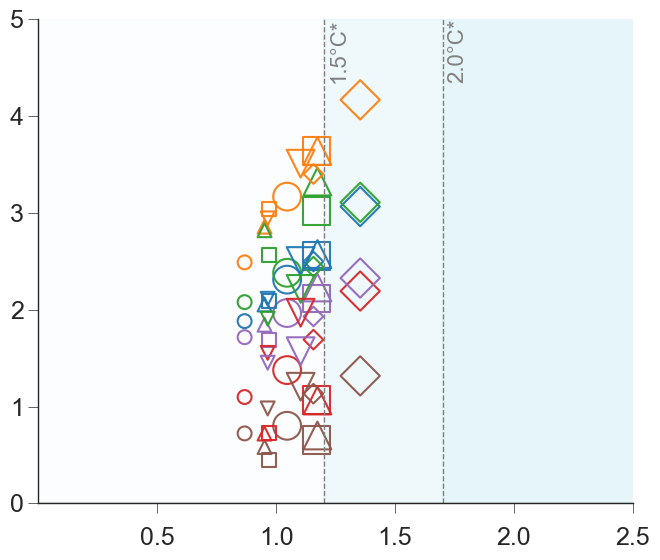

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Enable interactive plotting for VS Code
plt.ion()  # Turn on interactive mode

# === FILE PATH ===
file_path = "Tas_GlobalVSPrw.xlsx"

# === LOAD DATA ===
df = pd.read_excel(file_path, sheet_name="Sheet1")

# === FILTER FOR HISTORICAL PERIOD ONLY ===
df = df[df["Period"].isin(["126_Midterm", "585_Midterm"])]

# === MODEL MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Midterm': 100,   # Smaller size for 126_Midterm
    '585_Midterm': 400    # Larger size for 585_Midterm
}

# === REGION COLORS ===
region_colors = {
    'Global': '#1f77b4',
    'Tropics': '#ff7f0e',
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}
regions_order = list(region_colors.keys())

# === FILTER DATA ===
df = df[df["Region"].isin(regions_order)].copy()
df["Region"] = pd.Categorical(df["Region"], categories=regions_order, ordered=True)

# === PLOTTING ===
sns.set(style="ticks", context="talk")
fig, ax = plt.subplots(figsize=(7, 6))

# === Define axis limits first ===
x_vals = df["Global_Temp_change_°C"]
y_vals = df["Regional_change_mm"]

# Compute overall max needed (including IPCC lines)
data_max = max(x_vals.max(), y_vals.max(), 2.0)
lims_max = 2.5

# === ADD BACKGROUND COLOR REGIONS ===
# Light red background for 0 < X < 1.2
ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)

# Darker red background for 1.2 < X < 1.5
ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
ax.axvspan(1.7, 2.5, alpha=1, color='#e5f5f9', zorder=0)

# === Scatter plotting: manually draw per model for marker shape control
for model, marker in model_markers.items():
    sub = df[df["Model"] == model]
    for _, row in sub.iterrows():
        color = region_colors.get(row["Region"], "gray")
        
        # Get size based on period
        size = period_sizes.get(row["Period"], 40)

        # All markers are unfilled (outline only)
        ax.scatter(
            row["Global_Temp_change_°C"],
            row["Regional_change_mm"],
            marker=marker,
            s=size,
            edgecolor=color,
            facecolor='none',  # No fill for all markers
            linewidth=1.5,     # Slightly thicker edge for better visibility
            alpha=0.95
        )

# Set axis limits
ax.set_xlim(0, lims_max)
ax.set_ylim(0, 5)

# Set ticks every 0.25°C
ax.set_xticks(np.arange(0.5, lims_max + 0.01, 0.5))
ax.set_yticks(np.arange(0, 5 + 0.01, 1))

# === Reference lines
ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1, zorder=2)
ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1, zorder=2)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=1, zorder=2)  # solid y=0 line

# Inline labels at end of lines
ax.text(1.2 + 0.02, 5, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
ax.text(1.7 + 0.02, 5, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')

# Customize tick appearance to make them visible and sharp
ax.tick_params(
    axis='both',
    which='major',
    length=7,        # Tick length (in points)
    width=0.5,       # Tick line width
    direction='out', # 'in', 'out', or 'inout'
    labelsize=18     # Font size of tick labels
)

# === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.0)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_linewidth(1.0)

# Move X-axis to Y=0
ax.spines['bottom'].set_position(('data', 0))

# Move X-axis tick labels to Y=0
ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0

# === Custom Legend for Regions + Reference
legend_elements = (
    [Line2D([0], [0], marker='o', color='w', label=region,
            markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
     for region, color in region_colors.items()] +
    [
        Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limits (1.5°C, 2.0°C)")
    ]
)

# === REMOVE GRID ===
ax.grid(False)

# === DISPLAY AND SAVE ===
plt.tight_layout(pad=1.2)

# Save the figure BEFORE showing it
plt.savefig("Global_vs_Prw1.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_vs_Prw1.png'")

# Display in VS Code (interactive)
plt.show()

Longterm

Figure saved as 'Global_vs_Prw2.png'


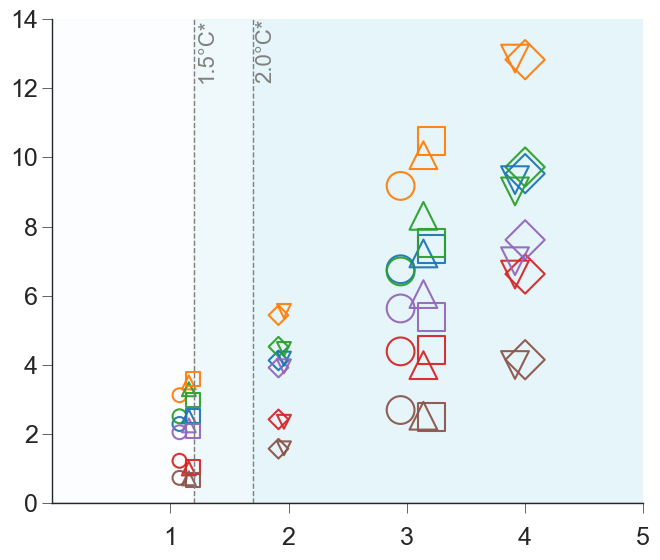

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Enable interactive plotting for VS Code
plt.ion()  # Turn on interactive mode

# === FILE PATH ===
file_path = "Tas_GlobalVSPrw.xlsx"

# === LOAD DATA ===
df = pd.read_excel(file_path, sheet_name="Sheet1")

# === FILTER FOR HISTORICAL PERIOD ONLY ===
df = df[df["Period"].isin(["126_Longterm", "585_Longterm"])]

# === MODEL MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Longterm': 100,   # Smaller size for 126_Midterm
    '585_Longterm': 400    # Larger size for 585_Midterm
}

# === REGION COLORS ===
region_colors = {
    'Global': '#1f77b4',
    'Tropics': '#ff7f0e',
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}
regions_order = list(region_colors.keys())

# === FILTER DATA ===
df = df[df["Region"].isin(regions_order)].copy()
df["Region"] = pd.Categorical(df["Region"], categories=regions_order, ordered=True)

# === PLOTTING ===
sns.set(style="ticks", context="talk")
fig, ax = plt.subplots(figsize=(7, 6))

# === Define axis limits first ===
x_vals = df["Global_Temp_change_°C"]
y_vals = df["Regional_change_mm"]

# Compute overall max needed (including IPCC lines)
data_max = max(x_vals.max(), y_vals.max(), 2.0)
lims_max = 5

# === ADD BACKGROUND COLOR REGIONS ===
# Light red background for 0 < X < 1.2
ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)

# Darker red background for 1.2 < X < 1.5
ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
ax.axvspan(1.7, 5, alpha=1, color='#e5f5f9', zorder=0)

# === Scatter plotting: manually draw per model for marker shape control
for model, marker in model_markers.items():
    sub = df[df["Model"] == model]
    for _, row in sub.iterrows():
        color = region_colors.get(row["Region"], "gray")
        
        # Get size based on period
        size = period_sizes.get(row["Period"], 40)

        # All markers are unfilled (outline only)
        ax.scatter(
            row["Global_Temp_change_°C"],
            row["Regional_change_mm"],
            marker=marker,
            s=size,
            edgecolor=color,
            facecolor='none',  # No fill for all markers
            linewidth=1.5,     # Slightly thicker edge for better visibility
            alpha=0.95
        )

# Set axis limits
ax.set_xlim(0, lims_max)
ax.set_ylim(0, 14)

# Set ticks every 0.25°C
ax.set_xticks(np.arange(1, lims_max + 0.02, 1))
ax.set_yticks(np.arange(0, 14 + 0.02, 2))

# === Reference lines
ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1, zorder=2)
ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1, zorder=2)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=1, zorder=2)  # solid y=0 line

# Inline labels at end of lines
ax.text(1.2 + 0.02, 14, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
ax.text(1.7 + 0.02, 14, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')

# Customize tick appearance to make them visible and sharp
ax.tick_params(
    axis='both',
    which='major',
    length=7,        # Tick length (in points)
    width=0.5,       # Tick line width
    direction='out', # 'in', 'out', or 'inout'
    labelsize=18     # Font size of tick labels
)

# === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.0)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_linewidth(1.0)

# Move X-axis to Y=0
ax.spines['bottom'].set_position(('data', 0))

# Move X-axis tick labels to Y=0
ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0

# === Custom Legend for Regions + Reference
legend_elements = (
    [Line2D([0], [0], marker='o', color='w', label=region,
            markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
     for region, color in region_colors.items()] +
    [
        Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limits (1.5°C, 2.0°C)")
    ]
)

# === REMOVE GRID ===
ax.grid(False)

# === DISPLAY AND SAVE ===
plt.tight_layout(pad=1.2)

# Save the figure BEFORE showing it
plt.savefig("Global_vs_Prw2.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_vs_Prw2.png'")

# Display in VS Code (interactive)
plt.show()

# Tas vs Pr

Historical

Figure saved as 'Global_vs_Pr0a.png'


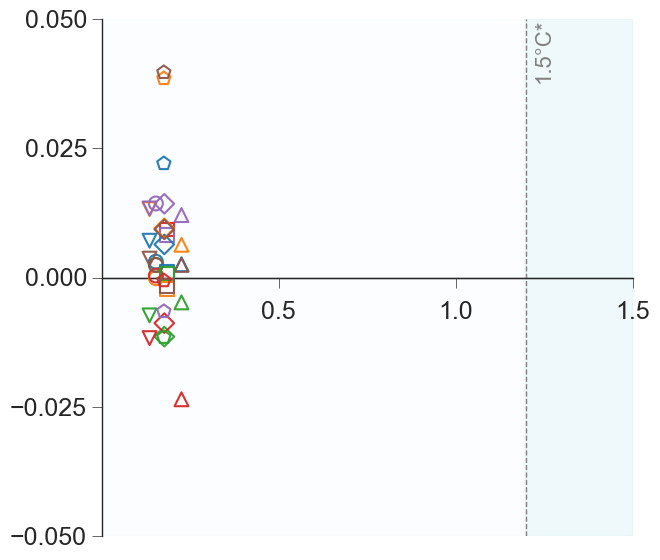

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Enable interactive plotting for VS Code
plt.ion()  # Turn on interactive mode

# === FILE PATH ===
file_path = "Tas_GlobalVSPr.xlsx"

# === LOAD DATA ===
df = pd.read_excel(file_path, sheet_name="Sheet1")

# === FILTER FOR HISTORICAL PERIOD ONLY ===
df = df[df["Period"] == "Historical"]

# === MODEL MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === REGION COLORS ===
region_colors = {
    'Global': '#1f77b4',
    'Tropics': '#ff7f0e',
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}
regions_order = list(region_colors.keys())

# === FILTER DATA ===
df = df[df["Region"].isin(regions_order)].copy()
df["Region"] = pd.Categorical(df["Region"], categories=regions_order, ordered=True)

# === PLOTTING ===
sns.set(style="ticks", context="talk")
fig, ax = plt.subplots(figsize=(7, 6))

# === Define axis limits first ===
x_vals = df["Global_Temp_change_°C"]
y_vals = df["Regional_change_mm/day"]

# Compute overall max needed (including IPCC lines)
data_max = max(x_vals.max(), y_vals.max(), 2.0)
lims_max = 1.5

# === ADD BACKGROUND COLOR REGIONS ===
# Light red background for 0 < X < 1.2
ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)

# Darker red background for 1.2 < X < 1.5
ax.axvspan(1.2, 1.5, alpha=0.6, color='#e5f5f9', zorder=0)

# === Scatter plotting: manually draw per model for marker shape control
for model, marker in model_markers.items():
    sub = df[df["Model"] == model]
    for _, row in sub.iterrows():
        color = region_colors.get(row["Region"], "gray")
        
        # All markers are unfilled (outline only)
        ax.scatter(
            row["Global_Temp_change_°C"],
            row["Regional_change_mm/day"],
            marker=marker,
            s=100,
            edgecolor=color,
            facecolor='none',  # No fill for all markers
            linewidth=1.5,     # Slightly thicker edge for better visibility
            alpha=0.95,
            zorder=3          # Make sure markers are on top
        )

# Set axis limits
ax.set_xlim(0, lims_max)
ax.set_ylim(-0.05, 0.05)

# Set ticks every 0.25°C
ax.set_xticks(np.arange(0.5, lims_max + 0.001, 0.5))
ax.set_yticks(np.arange(-0.05, 0.05 + 0.001, 0.025))

# === Reference lines
ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1, zorder=2)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=1, zorder=2)  # solid y=0 line

# Inline labels at end of lines
ax.text(1.2 + 0.02, 0.05, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')

# Customize tick appearance to make them visible and sharp
ax.tick_params(
    axis='both',
    which='major',
    length=7,        # Tick length (in points)
    width=0.5,       # Tick line width
    direction='out', # 'in', 'out', or 'inout'
    labelsize=18     # Font size of tick labels
)

# === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.0)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_linewidth(1.0)

# Move X-axis to Y=0
ax.spines['bottom'].set_position(('data', 0))

# Move X-axis tick labels to Y=0
ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0

# === Custom Legend for Regions + Reference
legend_elements = (
    [Line2D([0], [0], marker='o', color='w', label=region,
            markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
     for region, color in region_colors.items()] +
    [
        Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limits (1.5°C, 2.0°C)")
    ]
)

# === REMOVE GRID ===
ax.grid(False)

# === DISPLAY AND SAVE ===
plt.tight_layout(pad=1.2)

# Save the figure BEFORE showing it
plt.savefig("Global_vs_Pr0a.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_vs_Pr0a.png'")

# Display in VS Code (interactive)
plt.show()

Midterm

Figure saved as 'Global_vs_Pr1.png'


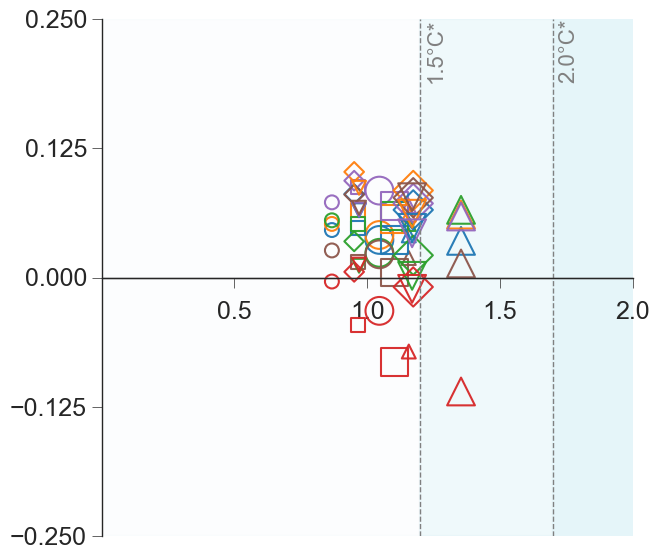

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Enable interactive plotting for VS Code
plt.ion()  # Turn on interactive mode

# === FILE PATH ===
file_path = "Tas_GlobalVSPr.xlsx"

# === LOAD DATA ===
df = pd.read_excel(file_path, sheet_name="Sheet1")

# === FILTER FOR MIDTERM SCENARIOS ONLY ===
df = df[df["Period"].isin(["126_Midterm", "585_Midterm"])]

# === MODEL MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Midterm': 100,   # Smaller size for 126_Midterm
    '585_Midterm': 400    # Larger size for 585_Midterm
}

# === REGION COLORS ===
region_colors = {
    'Global': '#1f77b4',
    'Tropics': '#ff7f0e',
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}
regions_order = list(region_colors.keys())

# === FILTER DATA ===
df = df[df["Region"].isin(regions_order)].copy()
df["Region"] = pd.Categorical(df["Region"], categories=regions_order, ordered=True)

# === PLOTTING ===
sns.set(style="ticks", context="talk")
fig, ax = plt.subplots(figsize=(7, 6))

# === ADD BACKGROUND COLOR REGIONS ===
# Light red background for 0 < X < 1.2
ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)

# Darker red background for 1.2 < X < 1.5
ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
ax.axvspan(1.7, 2.0, alpha=1.0, color='#e5f5f9', zorder=0)

# === Scatter plotting: manually draw per model for marker shape control
for model, marker in model_markers.items():
    sub = df[df["Model"] == model]
    for _, row in sub.iterrows():
        color = region_colors.get(row["Region"], "gray")
        
        # Get size based on period
        size = period_sizes.get(row["Period"], 40)

        # All markers are unfilled (outline only)
        ax.scatter(
            row["Global_Temp_change_°C"],
            row["Regional_change_mm/day"],
            marker=marker,
            s=size,
            edgecolor=color,
            facecolor='none',  # No fill for all markers
            linewidth=1.5,     # Slightly thicker edge for better visibility
            alpha=0.95
        )

# === Define axis limits starting at 0°C, aligned to 0.25°C, include IPCC lines
x_vals = df["Global_Temp_change_°C"]
y_vals = df["Regional_change_mm/day"]

# Compute overall max needed (including IPCC lines)
data_max = max(x_vals.max(), y_vals.max(), 2.0)
lims_max = 2.0

# Set axis limits
ax.set_xlim(0, lims_max)
ax.set_ylim(-0.25, 0.25)

# Set ticks every 0.25°C
ax.set_xticks(np.arange(0.5, lims_max + 0.001, 0.5))
ax.set_yticks(np.arange(-0.25, 0.25 + 0.001, 0.125))

# === Reference lines
ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1)
ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=1)  # solid y=0 line

# Inline labels at end of lines
ax.text(1.2 + 0.02, 0.25, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
ax.text(1.7 + 0.02, 0.25, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')

# Customize tick appearance to make them visible and sharp
ax.tick_params(
    axis='both',
    which='major',
    length=7,        # Tick length (in points)
    width=0.5,       # Tick line width
    direction='out', # 'in', 'out', or 'inout'
    labelsize=18     # Font size of tick labels
)

# === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.0)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_linewidth(1.0)

# Move X-axis to Y=0
ax.spines['bottom'].set_position(('data', 0))

# Move X-axis tick labels to Y=0
ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0

# === Custom Legend for Regions + Reference
legend_elements = (
    [Line2D([0], [0], marker='o', color='w', label=region,
            markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
     for region, color in region_colors.items()] +
    [
        Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limits (1.5°C, 2.0°C)")
    ]
)

# === REMOVE GRID ===
ax.grid(False)

# === DISPLAY AND SAVE ===
plt.tight_layout(pad=1.2)

# Save the figure BEFORE showing it
plt.savefig("Global_vs_Pr1.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_vs_Pr1.png'")

# Display in VS Code (interactive)
plt.show()

Longterm

Figure saved as 'Global_vs_Pr2.png'


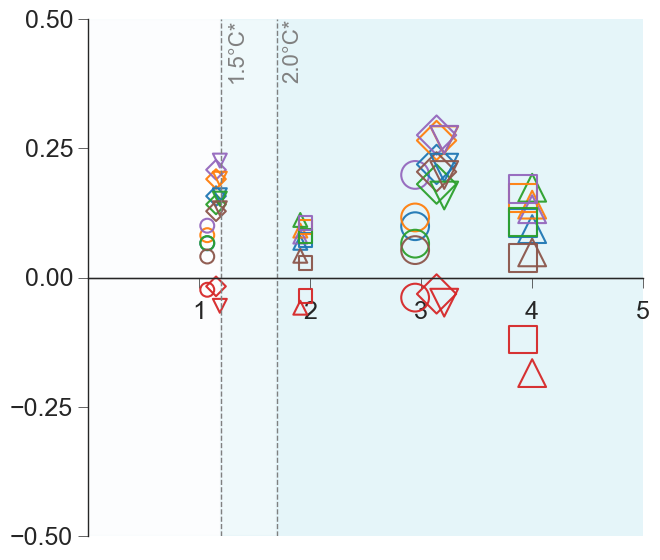

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Enable interactive plotting for VS Code
plt.ion()  # Turn on interactive mode

# === FILE PATH ===
file_path = "Tas_GlobalVSPr.xlsx"

# === LOAD DATA ===
df = pd.read_excel(file_path, sheet_name="Sheet1")

# === FILTER FOR LONGTERM SCENARIOS ONLY ===
df = df[df["Period"].isin(["126_Longterm", "585_Longterm"])]

# === MODEL MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Longterm': 100,   # Smaller size for 126_Longterm
    '585_Longterm': 400    # Larger size for 585_Longterm
}

# === REGION COLORS ===
region_colors = {
    'Global': '#1f77b4',
    'Tropics': '#ff7f0e',
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}
regions_order = list(region_colors.keys())

# === FILTER DATA ===
df = df[df["Region"].isin(regions_order)].copy()
df["Region"] = pd.Categorical(df["Region"], categories=regions_order, ordered=True)

# === PLOTTING ===
sns.set(style="ticks", context="talk")
fig, ax = plt.subplots(figsize=(7, 6))

# === ADD BACKGROUND COLOR REGIONS ===
# Light red background for 0 < X < 1.2
ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)

# Darker red background for 1.2 < X < 1.5
ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
ax.axvspan(1.7, 5.0, alpha=1.0, color='#e5f5f9', zorder=0)

# === Scatter plotting: manually draw per model for marker shape control
for model, marker in model_markers.items():
    sub = df[df["Model"] == model]
    for _, row in sub.iterrows():
        color = region_colors.get(row["Region"], "gray")
        
        # Get size based on period
        size = period_sizes.get(row["Period"], 40)

        # All markers are unfilled (outline only)
        ax.scatter(
            row["Global_Temp_change_°C"],
            row["Regional_change_mm/day"],
            marker=marker,
            s=size,
            edgecolor=color,
            facecolor='none',  # No fill for all markers
            linewidth=1.5,     # Slightly thicker edge for better visibility
            alpha=0.95
        )

# === Define axis limits starting at 0°C, aligned to 0.25°C, include IPCC lines
x_vals = df["Global_Temp_change_°C"]
y_vals = df["Regional_change_mm/day"]

# Compute overall max needed (including IPCC lines)
data_max = max(x_vals.max(), y_vals.max(), 2.0)
lims_max = 5.0

# Set axis limits
ax.set_xlim(0, lims_max)
ax.set_ylim(-0.5, 0.5)

# Set ticks every 0.25°C
ax.set_xticks(np.arange(1, lims_max + 0.001, 1))
ax.set_yticks(np.arange(-0.5, 0.5 + 0.001, 0.25))

# === Reference lines
ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1)
ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=1)  # solid y=0 line

# Inline labels at end of lines
ax.text(1.2 + 0.05, 0.5, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
ax.text(1.7 + 0.05, 0.5, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')

# Customize tick appearance to make them visible and sharp
ax.tick_params(
    axis='both',
    which='major',
    length=7,        # Tick length (in points)
    width=0.5,       # Tick line width
    direction='out', # 'in', 'out', or 'inout'
    labelsize=18     # Font size of tick labels
)

# === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.0)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_linewidth(1.0)

# Move X-axis to Y=0
ax.spines['bottom'].set_position(('data', 0))

# Move X-axis tick labels to Y=0
ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0

# === Custom Legend for Regions + Reference
legend_elements = (
    [Line2D([0], [0], marker='o', color='w', label=region,
            markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
     for region, color in region_colors.items()] +
    [
        Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limits (1.5°C, 2.0°C)")
    ]
)

# === REMOVE GRID ===
ax.grid(False)

# === DISPLAY AND SAVE ===
plt.tight_layout(pad=1.2)

# Save the figure BEFORE showing it
plt.savefig("Global_vs_Pr2.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_vs_Pr2.png'")

# Display in VS Code (interactive)
plt.show()

# Tas vs E0

Historical

Figure saved as 'Global_vs_E0.png'


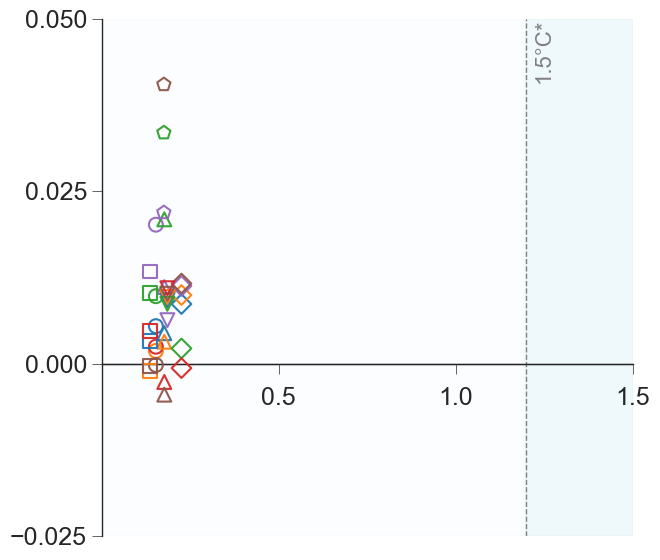

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Enable interactive plotting for VS Code
plt.ion()  # Turn on interactive mode

# === FILE PATH ===
file_path = "Tas_GlobalVSE.xlsx"

# === LOAD DATA ===
df = pd.read_excel(file_path, sheet_name="Sheet1")

# === FILTER FOR HISTORICAL PERIOD ONLY ===
df = df[df["Period"] == "Historical"]

# === MODEL MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === REGION COLORS ===
region_colors = {
    'Global': '#1f77b4',
    'Tropics': '#ff7f0e',
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}
regions_order = list(region_colors.keys())

# === FILTER DATA ===
df = df[df["Region"].isin(regions_order)].copy()
df["Region"] = pd.Categorical(df["Region"], categories=regions_order, ordered=True)

# === PLOTTING ===
sns.set(style="ticks", context="talk")
fig, ax = plt.subplots(figsize=(7, 6))

# === Define axis limits first ===
x_vals = df["Global_Temp_change_°C"]
y_vals = df["Regional_change_mm/day"]

# Compute overall max needed (including IPCC lines)
data_max = max(x_vals.max(), y_vals.max(), 2.0)
lims_max = 1.5

# === ADD BACKGROUND COLOR REGIONS ===
# Light red background for 0 < X < 1.2
ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)

# Darker red background for 1.2 < X < 1.5
ax.axvspan(1.2, 1.5, alpha=0.6, color='#e5f5f9', zorder=0)

# === Scatter plotting: manually draw per model for marker shape control
for model, marker in model_markers.items():
    sub = df[df["Model"] == model]
    for _, row in sub.iterrows():
        color = region_colors.get(row["Region"], "gray")
        
        # All markers are unfilled (outline only)
        ax.scatter(
            row["Global_Temp_change_°C"],
            row["Regional_change_mm/day"],
            marker=marker,
            s=100,
            edgecolor=color,
            facecolor='none',  # No fill for all markers
            linewidth=1.5,     # Slightly thicker edge for better visibility
            alpha=0.95,
            zorder=3          # Make sure markers are on top
        )

# Set axis limits
ax.set_xlim(0, lims_max)
ax.set_ylim(-0.025, 0.05)

# Set ticks every 0.25°C
ax.set_xticks(np.arange(0.5, lims_max + 0.001, 0.5))
ax.set_yticks(np.arange(-0.025, 0.05 + 0.001, 0.025))

# === Reference lines
ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1, zorder=2)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=1, zorder=2)  # solid y=0 line

# Inline labels at end of lines
ax.text(1.2 + 0.02, 0.05, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')

# Customize tick appearance to make them visible and sharp
ax.tick_params(
    axis='both',
    which='major',
    length=7,        # Tick length (in points)
    width=0.5,       # Tick line width
    direction='out', # 'in', 'out', or 'inout'
    labelsize=18     # Font size of tick labels
)

# === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.0)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_linewidth(1.0)

# Move X-axis to Y=0
ax.spines['bottom'].set_position(('data', 0))

# Move X-axis tick labels to Y=0
ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0

# === Custom Legend for Regions + Reference
legend_elements = (
    [Line2D([0], [0], marker='o', color='w', label=region,
            markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
     for region, color in region_colors.items()] +
    [
        Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limits (1.5°C, 2.0°C)")
    ]
)

# === REMOVE GRID ===
ax.grid(False)

# === DISPLAY AND SAVE ===
plt.tight_layout(pad=1.2)

# Save the figure BEFORE showing it
plt.savefig("Global_vs_E0.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_vs_E0.png'")

# Display in VS Code (interactive)
plt.show()

Midterm

Figure saved as 'Global_vs_E1.png'


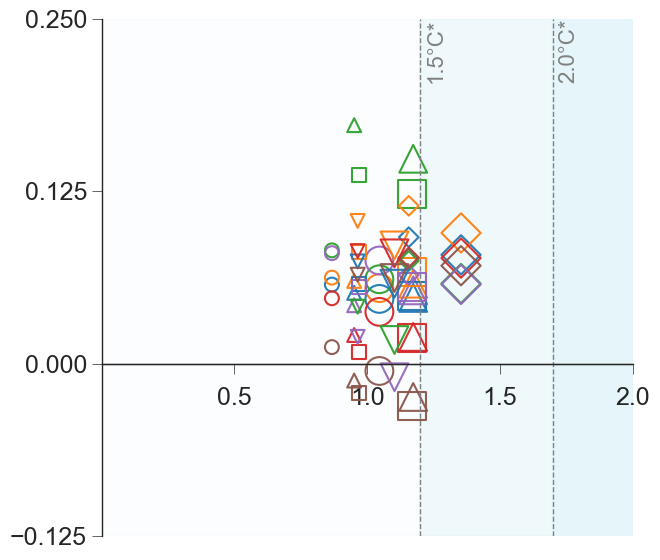

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Enable interactive plotting for VS Code
plt.ion()  # Turn on interactive mode

# === FILE PATH ===
file_path = "Tas_GlobalVSE.xlsx"

# === LOAD DATA ===
df = pd.read_excel(file_path, sheet_name="Sheet1")

# === FILTER FOR MIDTERM SCENARIOS ONLY ===
df = df[df["Period"].isin(["126_Midterm", "585_Midterm"])]

# === MODEL MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Midterm': 100,   # Smaller size for 126_Midterm
    '585_Midterm': 400    # Larger size for 585_Midterm
}

# === REGION COLORS ===
region_colors = {
    'Global': '#1f77b4',
    'Tropics': '#ff7f0e',
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}
regions_order = list(region_colors.keys())

# === FILTER DATA ===
df = df[df["Region"].isin(regions_order)].copy()
df["Region"] = pd.Categorical(df["Region"], categories=regions_order, ordered=True)

# === PLOTTING ===
sns.set(style="ticks", context="talk")
fig, ax = plt.subplots(figsize=(7, 6))

# === ADD BACKGROUND COLOR REGIONS ===
# Light red background for 0 < X < 1.2
ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)

# Darker red background for 1.2 < X < 1.5
ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
ax.axvspan(1.7, 2.0, alpha=1.0, color='#e5f5f9', zorder=0)

# === Scatter plotting: manually draw per model for marker shape control
for model, marker in model_markers.items():
    sub = df[df["Model"] == model]
    for _, row in sub.iterrows():
        color = region_colors.get(row["Region"], "gray")
        
        # Get size based on period
        size = period_sizes.get(row["Period"], 40)

        # All markers are unfilled (outline only)
        ax.scatter(
            row["Global_Temp_change_°C"],
            row["Regional_change_mm/day"],
            marker=marker,
            s=size,
            edgecolor=color,
            facecolor='none',  # No fill for all markers
            linewidth=1.5,     # Slightly thicker edge for better visibility
            alpha=0.95
        )

# === Define axis limits starting at 0°C, aligned to 0.25°C, include IPCC lines
x_vals = df["Global_Temp_change_°C"]
y_vals = df["Regional_change_mm/day"]

# Compute overall max needed (including IPCC lines)
data_max = max(x_vals.max(), y_vals.max(), 2.0)
lims_max = 2.0

# Set axis limits
ax.set_xlim(0, lims_max)
ax.set_ylim(-0.125, 0.25)

# Set ticks every 0.25°C
ax.set_xticks(np.arange(0.5, lims_max + 0.001, 0.5))
ax.set_yticks(np.arange(-0.125, 0.25 + 0.001, 0.125))

# === Reference lines
ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1)
ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=1)  # solid y=0 line

# Inline labels at end of lines
ax.text(1.2 + 0.02, 0.25, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
ax.text(1.7 + 0.02, 0.25, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')

# Customize tick appearance to make them visible and sharp
ax.tick_params(
    axis='both',
    which='major',
    length=7,        # Tick length (in points)
    width=0.5,       # Tick line width
    direction='out', # 'in', 'out', or 'inout'
    labelsize=18     # Font size of tick labels
)

# === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.0)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_linewidth(1.0)

# Move X-axis to Y=0
ax.spines['bottom'].set_position(('data', 0))

# Move X-axis tick labels to Y=0
ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0

# === Custom Legend for Regions + Reference
legend_elements = (
    [Line2D([0], [0], marker='o', color='w', label=region,
            markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
     for region, color in region_colors.items()] +
    [
        Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limits (1.5°C, 2.0°C)")
    ]
)

# === REMOVE GRID ===
ax.grid(False)

# === DISPLAY AND SAVE ===
plt.tight_layout(pad=1.2)

# Save the figure BEFORE showing it
plt.savefig("Global_vs_E1.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_vs_E1.png'")

# Display in VS Code (interactive)
plt.show()

Longterm

Figure saved as 'Global_vs_E2.png'


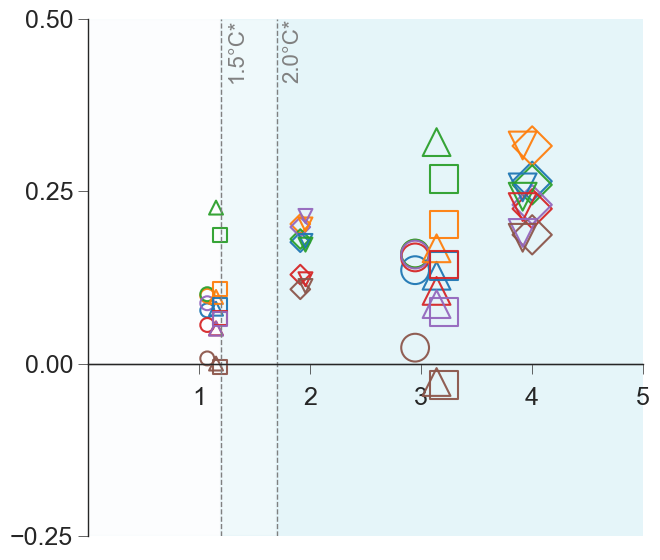

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Enable interactive plotting for VS Code
plt.ion()  # Turn on interactive mode

# === FILE PATH ===
file_path = "Tas_GlobalVSE.xlsx"

# === LOAD DATA ===
df = pd.read_excel(file_path, sheet_name="Sheet1")

# === FILTER FOR MIDTERM SCENARIOS ONLY ===
df = df[df["Period"].isin(["126_Longterm", "585_Longterm"])]

# === MODEL MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Longterm': 100,   # Smaller size for 126_Midterm
    '585_Longterm': 400    # Larger size for 585_Midterm
}

# === REGION COLORS ===
region_colors = {
    'Global': '#1f77b4',
    'Tropics': '#ff7f0e',
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}
regions_order = list(region_colors.keys())

# === FILTER DATA ===
df = df[df["Region"].isin(regions_order)].copy()
df["Region"] = pd.Categorical(df["Region"], categories=regions_order, ordered=True)

# === PLOTTING ===
sns.set(style="ticks", context="talk")
fig, ax = plt.subplots(figsize=(7, 6))

# === ADD BACKGROUND COLOR REGIONS ===
# Light red background for 0 < X < 1.2
ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)

# Darker red background for 1.2 < X < 1.5
ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
ax.axvspan(1.7, 5.0, alpha=1.0, color='#e5f5f9', zorder=0)

# === Scatter plotting: manually draw per model for marker shape control
for model, marker in model_markers.items():
    sub = df[df["Model"] == model]
    for _, row in sub.iterrows():
        color = region_colors.get(row["Region"], "gray")
        
        # Get size based on period
        size = period_sizes.get(row["Period"], 40)

        # All markers are unfilled (outline only)
        ax.scatter(
            row["Global_Temp_change_°C"],
            row["Regional_change_mm/day"],
            marker=marker,
            s=size,
            edgecolor=color,
            facecolor='none',  # No fill for all markers
            linewidth=1.5,     # Slightly thicker edge for better visibility
            alpha=0.95
        )

# === Define axis limits starting at 0°C, aligned to 0.25°C, include IPCC lines
x_vals = df["Global_Temp_change_°C"]
y_vals = df["Regional_change_mm/day"]

# Compute overall max needed (including IPCC lines)
data_max = max(x_vals.max(), y_vals.max(), 2.0)
lims_max = 5.0

# Set axis limits
ax.set_xlim(0, lims_max)
ax.set_ylim(-0.25, 0.5)

# Set ticks every 0.25°C
ax.set_xticks(np.arange(1, lims_max + 0.01, 1))
ax.set_yticks(np.arange(-0.25, 0.5 + 0.01, 0.25))

# === Reference lines
ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1)
ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=1)  # solid y=0 line

# Inline labels at end of lines
ax.text(1.2 + 0.05, 0.5, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
ax.text(1.7 + 0.05, 0.5, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')

# Customize tick appearance to make them visible and sharp
ax.tick_params(
    axis='both',
    which='major',
    length=7,        # Tick length (in points)
    width=0.5,       # Tick line width
    direction='out', # 'in', 'out', or 'inout'
    labelsize=18     # Font size of tick labels
)

# === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.0)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_linewidth(1.0)

# Move X-axis to Y=0
ax.spines['bottom'].set_position(('data', 0))

# Move X-axis tick labels to Y=0
ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0

# === Custom Legend for Regions + Reference
legend_elements = (
    [Line2D([0], [0], marker='o', color='w', label=region,
            markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
     for region, color in region_colors.items()] +
    [
        Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limits (1.5°C, 2.0°C)")
    ]
)

# === REMOVE GRID ===
ax.grid(False)

# === DISPLAY AND SAVE ===
plt.tight_layout(pad=1.2)

# Save the figure BEFORE showing it
plt.savefig("Global_vs_E2.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_vs_E2.png'")

# Display in VS Code (interactive)
plt.show()

# Tas vs SM

Historical

Figure saved as 'Global_vs_SM0.png'


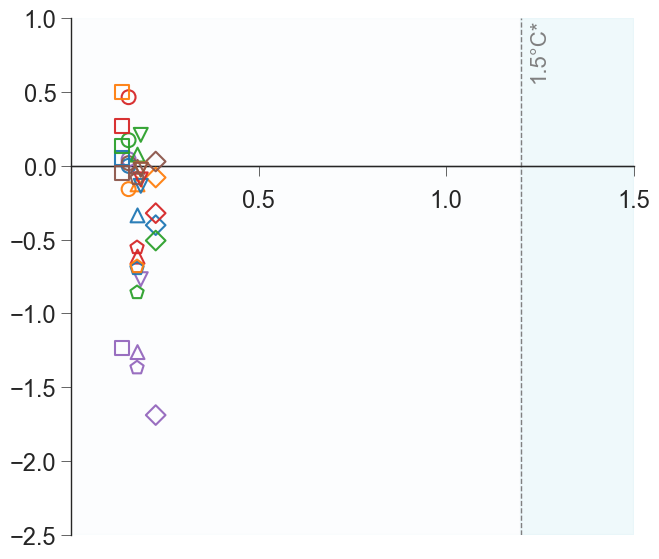

In [67]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Enable interactive plotting for VS Code
plt.ion()  # Turn on interactive mode

# === FILE PATH ===
file_path = "Tas_GlobalVSSM.xlsx"

# === LOAD DATA ===
df = pd.read_excel(file_path, sheet_name="Sheet1")

# === FILTER FOR HISTORICAL PERIOD ONLY ===
df = df[df["Period"] == "Historical"]

# === MODEL MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === REGION COLORS ===
region_colors = {
    'Global': '#1f77b4',
    'Tropics': '#ff7f0e',
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}
regions_order = list(region_colors.keys())

# === FILTER DATA ===
df = df[df["Region"].isin(regions_order)].copy()
df["Region"] = pd.Categorical(df["Region"], categories=regions_order, ordered=True)

# === SCALE y-variable ===
df["Regional_change_m3/m3"] = df["Regional_change_m3/m3"] * 1000

# === PLOTTING ===
sns.set(style="ticks", context="talk")
fig, ax = plt.subplots(figsize=(7, 6))

# === Define axis limits first ===
x_vals = df["Global_Temp_change_°C"]
y_vals = df["Regional_change_m3/m3"]

# Compute overall max needed (including IPCC lines)
data_max = max(x_vals.max(), y_vals.max(), 2.0)
lims_max = 1.5

# === ADD BACKGROUND COLOR REGIONS ===
# Light red background for 0 < X < 1.2
ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)

# Darker red background for 1.2 < X < 1.5
ax.axvspan(1.2, 1.5, alpha=0.6, color='#e5f5f9', zorder=0)

# === Scatter plotting: manually draw per model for marker shape control
for model, marker in model_markers.items():
    sub = df[df["Model"] == model]
    for _, row in sub.iterrows():
        color = region_colors.get(row["Region"], "gray")
        
        # All markers are unfilled (outline only)
        ax.scatter(
            row["Global_Temp_change_°C"],
            row["Regional_change_m3/m3"],
            marker=marker,
            s=100,
            edgecolor=color,
            facecolor='none',  # No fill for all markers
            linewidth=1.5,     # Slightly thicker edge for better visibility
            alpha=0.95,
            zorder=3          # Make sure markers are on top
        )

# Set axis limits
ax.set_xlim(0, lims_max)
ax.set_ylim(-2.5, 1)

# Set ticks every 0.25°C
ax.set_xticks(np.arange(0.5, lims_max + 0.001, 0.5))
ax.set_yticks(np.arange(-2.5, 1 + 0.01, 0.5))

# === Reference lines
ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1, zorder=2)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=1, zorder=2)  # solid y=0 line

# Inline labels at end of lines
ax.text(1.2 + 0.02, 1, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')

# Customize tick appearance to make them visible and sharp
ax.tick_params(
    axis='both',
    which='major',
    length=7,        # Tick length (in points)
    width=0.5,       # Tick line width
    direction='out', # 'in', 'out', or 'inout'
    labelsize=17     # Font size of tick labels
)

# === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.0)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_linewidth(1.0)

# Move X-axis to Y=0
ax.spines['bottom'].set_position(('data', 0))

# Move X-axis tick labels to Y=0
ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0

# === Custom Legend for Regions + Reference
legend_elements = (
    [Line2D([0], [0], marker='o', color='w', label=region,
            markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
     for region, color in region_colors.items()] +
    [
        Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limits (1.5°C, 2.0°C)")
    ]
)

# === REMOVE GRID ===
ax.grid(False)

# === DISPLAY AND SAVE ===
plt.tight_layout(pad=1.2)

# Save the figure BEFORE showing it
plt.savefig("Global_vs_SM0.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_vs_SM0.png'")

# Display in VS Code (interactive)
plt.show()

Midterm

Figure saved as 'Global_vs_SM1.png'


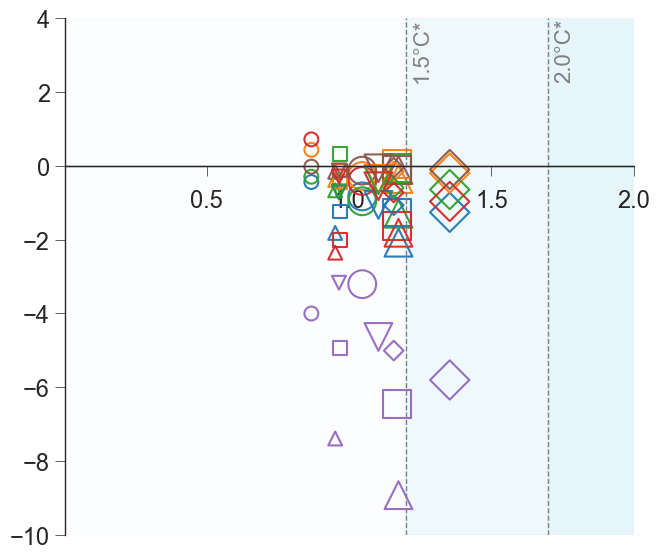

In [66]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Enable interactive plotting for VS Code
plt.ion()  # Turn on interactive mode

# === FILE PATH ===
file_path = "Tas_GlobalVSSM.xlsx"

# === LOAD DATA ===
df = pd.read_excel(file_path, sheet_name="Sheet1")

# === FILTER FOR MIDTERM SCENARIOS ONLY ===
df = df[df["Period"].isin(["126_Midterm", "585_Midterm"])]

# === MODEL MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Midterm': 100,   # Smaller size for 126_Midterm
    '585_Midterm': 400    # Larger size for 585_Midterm
}

# === REGION COLORS ===
region_colors = {
    'Global': '#1f77b4',
    'Tropics': '#ff7f0e',
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}
regions_order = list(region_colors.keys())

# === FILTER DATA ===
df = df[df["Region"].isin(regions_order)].copy()
df["Region"] = pd.Categorical(df["Region"], categories=regions_order, ordered=True)

# === SCALE y-variable ===
df["Regional_change_m3/m3"] = df["Regional_change_m3/m3"] * 1000

# === PLOTTING ===
sns.set(style="ticks", context="talk")
fig, ax = plt.subplots(figsize=(7, 6))

# === ADD BACKGROUND COLOR REGIONS ===
# Light red background for 0 < X < 1.2
ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)

# Darker red background for 1.2 < X < 1.5
ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
ax.axvspan(1.7, 2.0, alpha=1.0, color='#e5f5f9', zorder=0)

# === Scatter plotting: manually draw per model for marker shape control
for model, marker in model_markers.items():
    sub = df[df["Model"] == model]
    for _, row in sub.iterrows():
        color = region_colors.get(row["Region"], "gray")
        
        # Get size based on period
        size = period_sizes.get(row["Period"], 40)

        # All markers are unfilled (outline only)
        ax.scatter(
            row["Global_Temp_change_°C"],
            row["Regional_change_m3/m3"],
            marker=marker,
            s=size,
            edgecolor=color,
            facecolor='none',  # No fill for all markers
            linewidth=1.5,     # Slightly thicker edge for better visibility
            alpha=0.95
        )

# === Define axis limits starting at 0°C, aligned to 0.25°C, include IPCC lines
x_vals = df["Global_Temp_change_°C"]
y_vals = df["Regional_change_m3/m3"]

# Compute overall max needed (including IPCC lines)
data_max = max(x_vals.max(), y_vals.max(), 2.0)
lims_max = 2.0

# Set axis limits
ax.set_xlim(0, lims_max)
ax.set_ylim(-10, 4)

# Set ticks every 0.25°C
ax.set_xticks(np.arange(0.5, lims_max + 0.001, 0.5))
ax.set_yticks(np.arange(-10, 4 + 0.01, 2))

# === Reference lines
ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1)
ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=1)  # solid y=0 line

# Inline labels at end of lines
ax.text(1.2 + 0.02, 4, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
ax.text(1.7 + 0.02, 4, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')

# Customize tick appearance to make them visible and sharp
ax.tick_params(
    axis='both',
    which='major',
    length=7,        # Tick length (in points)
    width=0.5,       # Tick line width
    direction='out', # 'in', 'out', or 'inout'
    labelsize=17     # Font size of tick labels
)

# === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.0)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_linewidth(1.0)

# Move X-axis to Y=0
ax.spines['bottom'].set_position(('data', 0))

# Move X-axis tick labels to Y=0
ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0

# === Custom Legend for Regions + Reference
legend_elements = (
    [Line2D([0], [0], marker='o', color='w', label=region,
            markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
     for region, color in region_colors.items()] +
    [
        Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limits (1.5°C, 2.0°C)")
    ]
)

# === REMOVE GRID ===
ax.grid(False)

# === DISPLAY AND SAVE ===
plt.tight_layout(pad=1.2)

# Save the figure BEFORE showing it
plt.savefig("Global_vs_SM1.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_vs_SM1.png'")

# Display in VS Code (interactive)
plt.show()

Longterm

Figure saved as 'Global_vs_SM2.png'


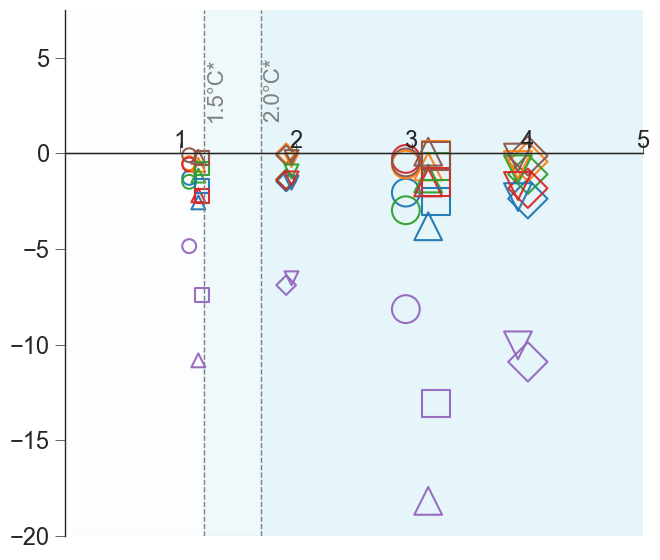

In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Enable interactive plotting for VS Code
plt.ion()  # Turn on interactive mode

# === FILE PATH ===
file_path = "Tas_GlobalVSSM.xlsx"

# === LOAD DATA ===
df = pd.read_excel(file_path, sheet_name="Sheet1")

# === FILTER FOR MIDTERM SCENARIOS ONLY ===
df = df[df["Period"].isin(["126_Longterm", "585_Longterm"])]

# === MODEL MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Longterm': 100,   # Smaller size for 126_Midterm
    '585_Longterm': 400    # Larger size for 585_Midterm
}

# === REGION COLORS ===
region_colors = {
    'Global': '#1f77b4',
    'Tropics': '#ff7f0e',
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}
regions_order = list(region_colors.keys())

# === FILTER DATA ===
df = df[df["Region"].isin(regions_order)].copy()
df["Region"] = pd.Categorical(df["Region"], categories=regions_order, ordered=True)

# === SCALE y-variable ===
df["Regional_change_m3/m3"] = df["Regional_change_m3/m3"] * 1000

# === PLOTTING ===
sns.set(style="ticks", context="talk")
fig, ax = plt.subplots(figsize=(7, 6))

# === ADD BACKGROUND COLOR REGIONS ===
# Light red background for 0 < X < 1.2
ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)

# Darker red background for 1.2 < X < 1.5
ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
ax.axvspan(1.7, 5.0, alpha=1.0, color='#e5f5f9', zorder=0)

# === Scatter plotting: manually draw per model for marker shape control
for model, marker in model_markers.items():
    sub = df[df["Model"] == model]
    for _, row in sub.iterrows():
        color = region_colors.get(row["Region"], "gray")
        
        # Get size based on period
        size = period_sizes.get(row["Period"], 40)

        # All markers are unfilled (outline only)
        ax.scatter(
            row["Global_Temp_change_°C"],
            row["Regional_change_m3/m3"],
            marker=marker,
            s=size,
            edgecolor=color,
            facecolor='none',  # No fill for all markers
            linewidth=1.5,     # Slightly thicker edge for better visibility
            alpha=0.95
        )

# === Define axis limits starting at 0°C, aligned to 0.25°C, include IPCC lines
x_vals = df["Global_Temp_change_°C"]
y_vals = df["Regional_change_m3/m3"]

# Compute overall max needed (including IPCC lines)
data_max = max(x_vals.max(), y_vals.max(), 2.0)
lims_max = 5.0
x_min = 0

# Set axis limits
ax.set_xlim(x_min, lims_max)
ax.set_ylim(-20, 7.5)

# Set ticks every 0.25°C
ax.set_xticks(np.arange(1, lims_max + 0.001, 1))
ax.set_yticks(np.arange(-20, 7.5 + 0.01, 5))

# === Reference lines
ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1)
ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=1)  # solid y=0 line

# Inline labels at end of lines
ax.text(1.2 + 0.02, 5, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
ax.text(1.7 + 0.02, 5, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')

# Customize tick appearance to make them visible and sharp
ax.tick_params(
    axis='both',
    which='major',
    length=7,        # Tick length (in points)
    width=0.5,       # Tick line width
    direction='out', # 'in', 'out', or 'inout'
    labelsize=17     # Font size of tick labels
)

# Customize x-axis ticks to point upward (since labels are above)
ax.tick_params(
    axis='x',
    which='major',
    length=7,        # Tick length (in points)
    width=0.5,       # Tick line width
    direction='in',  # Point inward (upward from x-axis)
    labelsize=17,    # Font size of tick labels
    labelbottom=False # Remove default labels below
)

# === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.0)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_linewidth(1.0)

# Move X-axis to Y=0
ax.spines['bottom'].set_position(('data', 0))

# Move X-axis tick labels to Y=0
ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0

# Add x-axis labels manually positioned just above the x-line
for set_xticks in ax.get_xticks():
    if x_min <= set_xticks <= lims_max:
        ax.text(set_xticks, 0.02, str(int(set_xticks)), ha='center', va='bottom', fontsize=17)

# === Custom Legend for Regions + Reference
legend_elements = (
    [Line2D([0], [0], marker='o', color='w', label=region,
            markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
     for region, color in region_colors.items()] +
    [
        Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limits (1.5°C, 2.0°C)")
    ]
)

# === REMOVE GRID ===
ax.grid(False)

# === DISPLAY AND SAVE ===
plt.tight_layout(pad=1.2)

# Save the figure BEFORE showing it
plt.savefig("Global_vs_SM2.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_vs_SM2.png'")

# Display in VS Code (interactive)
plt.show()

# Tas vs q

Historical

Figure saved as 'Global_vs_q0.png'


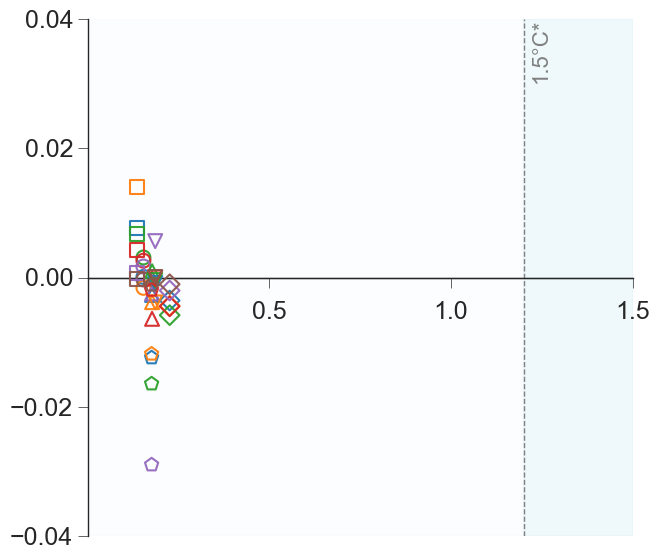

In [78]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Enable interactive plotting for VS Code
plt.ion()  # Turn on interactive mode

# === FILE PATH ===
file_path = "Tas_GlobalVSRunoff.xlsx"

# === LOAD DATA ===
df = pd.read_excel(file_path, sheet_name="Sheet1")

# === FILTER FOR HISTORICAL PERIOD ONLY ===
df = df[df["Period"] == "Historical"]

# === MODEL MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === REGION COLORS ===
region_colors = {
    'Global': '#1f77b4',
    'Tropics': '#ff7f0e',
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}
regions_order = list(region_colors.keys())

# === FILTER DATA ===
df = df[df["Region"].isin(regions_order)].copy()
df["Region"] = pd.Categorical(df["Region"], categories=regions_order, ordered=True)

# === PLOTTING ===
sns.set(style="ticks", context="talk")
fig, ax = plt.subplots(figsize=(7, 6))

# === Define axis limits first ===
x_vals = df["Global_Temp_change_°C"]
y_vals = df["Regional_change_mm/day"]

# Compute overall max needed (including IPCC lines)
data_max = max(x_vals.max(), y_vals.max(), 2.0)
lims_max = 1.5

# === ADD BACKGROUND COLOR REGIONS ===
# Light red background for 0 < X < 1.2
ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)

# Darker red background for 1.2 < X < 1.5
ax.axvspan(1.2, 1.5, alpha=0.6, color='#e5f5f9', zorder=0)

# === Scatter plotting: manually draw per model for marker shape control
for model, marker in model_markers.items():
    sub = df[df["Model"] == model]
    for _, row in sub.iterrows():
        color = region_colors.get(row["Region"], "gray")
        
        # All markers are unfilled (outline only)
        ax.scatter(
            row["Global_Temp_change_°C"],
            row["Regional_change_mm/day"],
            marker=marker,
            s=100,
            edgecolor=color,
            facecolor='none',  # No fill for all markers
            linewidth=1.5,     # Slightly thicker edge for better visibility
            alpha=0.95,
            zorder=3          # Make sure markers are on top
        )

# Set axis limits
ax.set_xlim(0, lims_max)
ax.set_ylim(-0.04, 0.04)

# Set ticks every 0.25°C
ax.set_xticks(np.arange(0.5, lims_max + 0.001, 0.5))
ax.set_yticks(np.arange(-0.04, 0.04 + 0.001, 0.02))

# === Reference lines
ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1, zorder=2)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=1, zorder=2)  # solid y=0 line

# Inline labels at end of lines
ax.text(1.2 + 0.02, 0.04, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')

# Customize tick appearance to make them visible and sharp
ax.tick_params(
    axis='both',
    which='major',
    length=7,        # Tick length (in points)
    width=0.5,       # Tick line width
    direction='out', # 'in', 'out', or 'inout'
    labelsize=18     # Font size of tick labels
)

# === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.0)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_linewidth(1.0)

# Move X-axis to Y=0
ax.spines['bottom'].set_position(('data', 0))

# Move X-axis tick labels to Y=0
ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0

# === Custom Legend for Regions + Reference
legend_elements = (
    [Line2D([0], [0], marker='o', color='w', label=region,
            markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
     for region, color in region_colors.items()] +
    [
        Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limits (1.5°C, 2.0°C)")
    ]
)

# === REMOVE GRID ===
ax.grid(False)

# === DISPLAY AND SAVE ===
plt.tight_layout(pad=1.2)

# Save the figure BEFORE showing it
plt.savefig("Global_vs_q0.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_vs_q0.png'")

# Display in VS Code (interactive)
plt.show()

Midterm

Figure saved as 'Global_vs_q1.png'


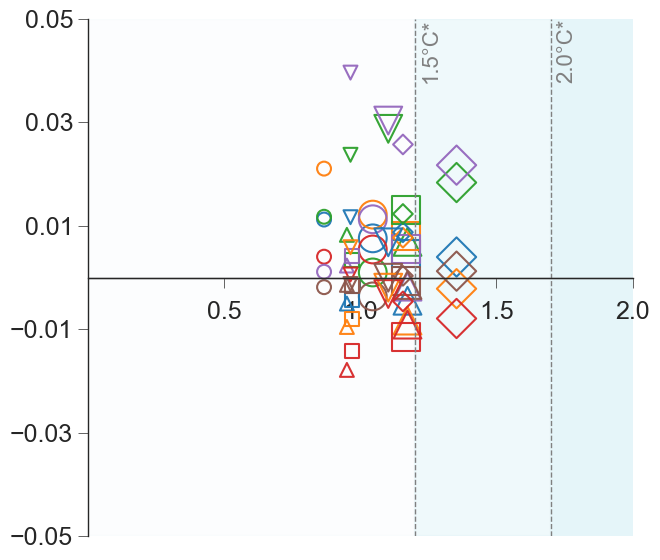

In [72]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Enable interactive plotting for VS Code
plt.ion()  # Turn on interactive mode

# === FILE PATH ===
file_path = "Tas_GlobalVSRunoff.xlsx"

# === LOAD DATA ===
df = pd.read_excel(file_path, sheet_name="Sheet1")

# === FILTER FOR MIDTERM SCENARIOS ONLY ===
df = df[df["Period"].isin(["126_Midterm", "585_Midterm"])]

# === MODEL MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Midterm': 100,   # Smaller size for 126_Midterm
    '585_Midterm': 400    # Larger size for 585_Midterm
}

# === REGION COLORS ===
region_colors = {
    'Global': '#1f77b4',
    'Tropics': '#ff7f0e',
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}
regions_order = list(region_colors.keys())

# === FILTER DATA ===
df = df[df["Region"].isin(regions_order)].copy()
df["Region"] = pd.Categorical(df["Region"], categories=regions_order, ordered=True)

# === PLOTTING ===
sns.set(style="ticks", context="talk")
fig, ax = plt.subplots(figsize=(7, 6))

# === ADD BACKGROUND COLOR REGIONS ===
# Light red background for 0 < X < 1.2
ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)

# Darker red background for 1.2 < X < 1.5
ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
ax.axvspan(1.7, 2.0, alpha=1.0, color='#e5f5f9', zorder=0)

# === Scatter plotting: manually draw per model for marker shape control
for model, marker in model_markers.items():
    sub = df[df["Model"] == model]
    for _, row in sub.iterrows():
        color = region_colors.get(row["Region"], "gray")
        
        # Get size based on period
        size = period_sizes.get(row["Period"], 40)

        # All markers are unfilled (outline only)
        ax.scatter(
            row["Global_Temp_change_°C"],
            row["Regional_change_mm/day"],
            marker=marker,
            s=size,
            edgecolor=color,
            facecolor='none',  # No fill for all markers
            linewidth=1.5,     # Slightly thicker edge for better visibility
            alpha=0.95
        )

# === Define axis limits starting at 0°C, aligned to 0.25°C, include IPCC lines
x_vals = df["Global_Temp_change_°C"]
y_vals = df["Regional_change_mm/day"]

# Compute overall max needed (including IPCC lines)
data_max = max(x_vals.max(), y_vals.max(), 2.0)
lims_max = 2.0

# Set axis limits
ax.set_xlim(0, lims_max)
ax.set_ylim(-0.05, 0.05)

# Set ticks every 0.25°C
ax.set_xticks(np.arange(0.5, lims_max + 0.001, 0.5))
ax.set_yticks(np.arange(-0.05, 0.05 + 0.001, 0.02))

# === Reference lines
ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1)
ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=1)  # solid y=0 line

# Inline labels at end of lines
ax.text(1.2 + 0.02, 0.05, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
ax.text(1.7 + 0.02, 0.05, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')

# Customize tick appearance to make them visible and sharp
ax.tick_params(
    axis='both',
    which='major',
    length=7,        # Tick length (in points)
    width=0.5,       # Tick line width
    direction='out', # 'in', 'out', or 'inout'
    labelsize=18     # Font size of tick labels
)

# === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.0)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_linewidth(1.0)

# Move X-axis to Y=0
ax.spines['bottom'].set_position(('data', 0))

# Move X-axis tick labels to Y=0
ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0

# === Custom Legend for Regions + Reference
legend_elements = (
    [Line2D([0], [0], marker='o', color='w', label=region,
            markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
     for region, color in region_colors.items()] +
    [
        Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limits (1.5°C, 2.0°C)")
    ]
)

# === REMOVE GRID ===
ax.grid(False)

# === DISPLAY AND SAVE ===
plt.tight_layout(pad=1.2)

# Save the figure BEFORE showing it
plt.savefig("Global_vs_q1.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_vs_q1.png'")

# Display in VS Code (interactive)
plt.show()

Longterm

Figure saved as 'Global_vs_q2.png'


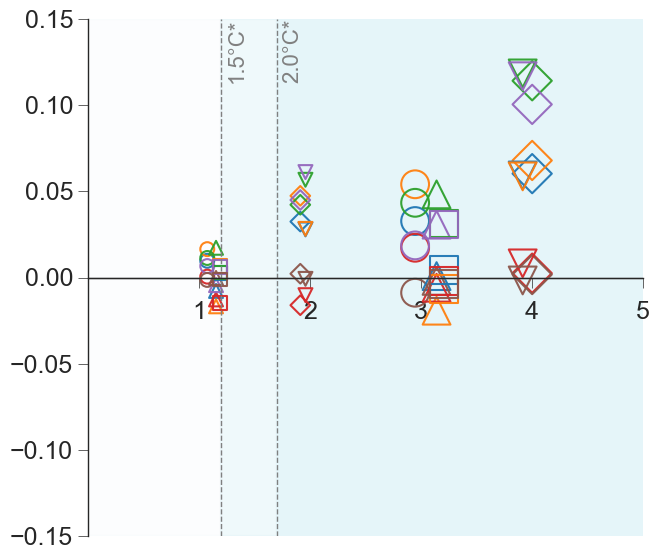

In [81]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Enable interactive plotting for VS Code
plt.ion()  # Turn on interactive mode

# === FILE PATH ===
file_path = "Tas_GlobalVSRunoff.xlsx"

# === LOAD DATA ===
df = pd.read_excel(file_path, sheet_name="Sheet1")

# === FILTER FOR MIDTERM SCENARIOS ONLY ===
df = df[df["Period"].isin(["126_Longterm", "585_Longterm"])]

# === MODEL MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Longterm': 100,   # Smaller size for 126_Midterm
    '585_Longterm': 400    # Larger size for 585_Midterm
}

# === REGION COLORS ===
region_colors = {
    'Global': '#1f77b4',
    'Tropics': '#ff7f0e',
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}
regions_order = list(region_colors.keys())

# === FILTER DATA ===
df = df[df["Region"].isin(regions_order)].copy()
df["Region"] = pd.Categorical(df["Region"], categories=regions_order, ordered=True)

# === PLOTTING ===
sns.set(style="ticks", context="talk")
fig, ax = plt.subplots(figsize=(7, 6))

# === ADD BACKGROUND COLOR REGIONS ===
# Light red background for 0 < X < 1.2
ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)

# Darker red background for 1.2 < X < 1.5
ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
ax.axvspan(1.7, 5.0, alpha=1.0, color='#e5f5f9', zorder=0)

# === Scatter plotting: manually draw per model for marker shape control
for model, marker in model_markers.items():
    sub = df[df["Model"] == model]
    for _, row in sub.iterrows():
        color = region_colors.get(row["Region"], "gray")
        
        # Get size based on period
        size = period_sizes.get(row["Period"], 40)

        # All markers are unfilled (outline only)
        ax.scatter(
            row["Global_Temp_change_°C"],
            row["Regional_change_mm/day"],
            marker=marker,
            s=size,
            edgecolor=color,
            facecolor='none',  # No fill for all markers
            linewidth=1.5,     # Slightly thicker edge for better visibility
            alpha=0.95
        )

# === Define axis limits starting at 0°C, aligned to 0.25°C, include IPCC lines
x_vals = df["Global_Temp_change_°C"]
y_vals = df["Regional_change_mm/day"]

# Compute overall max needed (including IPCC lines)
data_max = max(x_vals.max(), y_vals.max(), 2.0)
lims_max = 5.0

# Set axis limits
ax.set_xlim(0, lims_max)
ax.set_ylim(-0.15, 0.15)

# Set ticks every 0.25°C
ax.set_xticks(np.arange(1, lims_max + 0.001, 1))
ax.set_yticks(np.arange(-0.15, 0.15 + 0.001, 0.05))

# === Reference lines
ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1)
ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=1)  # solid y=0 line

# Inline labels at end of lines
ax.text(1.2 + 0.05, 0.15, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
ax.text(1.7 + 0.05, 0.15, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')

# Customize tick appearance to make them visible and sharp
ax.tick_params(
    axis='both',
    which='major',
    length=7,        # Tick length (in points)
    width=0.5,       # Tick line width
    direction='out', # 'in', 'out', or 'inout'
    labelsize=18     # Font size of tick labels
)

# === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.0)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_linewidth(1.0)

# Move X-axis to Y=0
ax.spines['bottom'].set_position(('data', 0))

# Move X-axis tick labels to Y=0
ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0

# === Custom Legend for Regions + Reference
legend_elements = (
    [Line2D([0], [0], marker='o', color='w', label=region,
            markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
     for region, color in region_colors.items()] +
    [
        Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limits (1.5°C, 2.0°C)")
    ]
)

# === REMOVE GRID ===
ax.grid(False)

# === DISPLAY AND SAVE ===
plt.tight_layout(pad=1.2)

# Save the figure BEFORE showing it
plt.savefig("Global_vs_q2.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_vs_q2.png'")

# Display in VS Code (interactive)
plt.show()